### Decision Tree
Birden fazla öznitelik içinden en kaliteli nitelik bulunarak daha detaya inilir.  En kaliteli öznitelikten yola çıkılarak daha doğru sonuca ulaşmak amaçlanır. 
Giriş verisi bir kümeleme algoritması yardımı ile tekrar tekrar gruplara bölünür.
2 aşamadan oluşur : birincisi ağacı oluşturma ve ikinci aşama ise ağaç budamadır. Budama işleminde gürültülü verilerden kurtulmak amaçlanır. 

**Ağaç oluştururken çeşitli yaklaşımlar sergilenebilir.**
* Entropiye Dayalı (ID3, C4.5)
* Regresyon ve Sınıflandırma
* Bellek Tabanlı (KNN) 

**Entropi:** bir süreç için tüm örnekler tarafından içerilen enformasyonun beklenen değeri. 

- ID3 Algoritması : 
Sadece kategorik veri ile çalışan bir yöntemdir. Yani verini ayrık olması gerekir. 
Her iterasyonun ilk adımında her özellik vektörünün entropisi hesaplanır. 
Daha sonra sınıfa bağlı entropi hesaplanır ve ilk adımda hesaplanan entropiden çıkarılarak bilgi kazancı elde edilir. 

bütün örnekler aynı sınıfta ise entropi 0 
0-1 arasında ise eşit dağılmış 

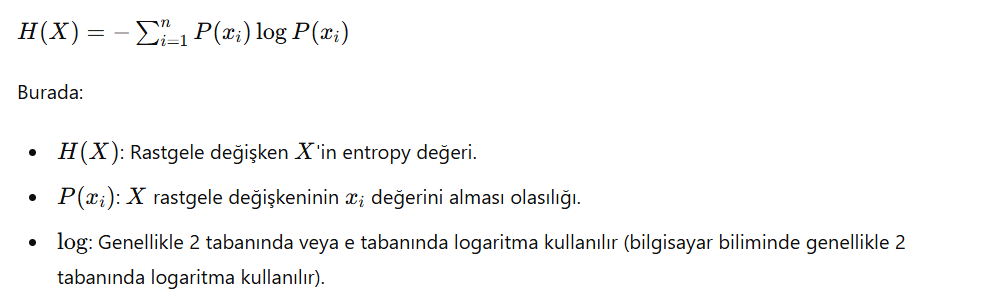
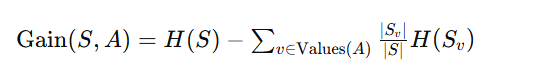

Dataset uzunluk:  625
Dataset boyutu:  (625, 5)
Dataset:     0  1  2  3  4
0  B  1  1  1  1
1  R  1  1  1  2
2  R  1  1  1  3
3  R  1  1  1  4
4  R  1  1  1  5
     0  1  2  3  4
0    B  1  1  1  1
1    R  1  1  1  2
2    R  1  1  1  3
3    R  1  1  1  4
4    R  1  1  1  5
..  .. .. .. .. ..
620  L  5  5  5  1
621  L  5  5  5  2
622  L  5  5  5  3
623  L  5  5  5  4
624  B  5  5  5  5

[625 rows x 5 columns]
-----------------------------------------------------------------------
L etiket sayısı:  288
R etiket sayısı:  288
B etiket sayısı:  49
-----------------------------------------------------------------------
Gini Ağacı
Gini index kullanarak sonuçlar:
Tahmin Edilen Değerler
['L' 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'L' 'R' 'R' 'L'
 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L'
 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'L'
 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'L' 'R' 'R' 'R' 'R' 'L' 'L' 'R'
 'L' 'R' 'R' 'L' 'R' 

C:\Users\sukri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\sukri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\sukri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\sukri\anaconda3\Lib\site-packages\sklearn\metr

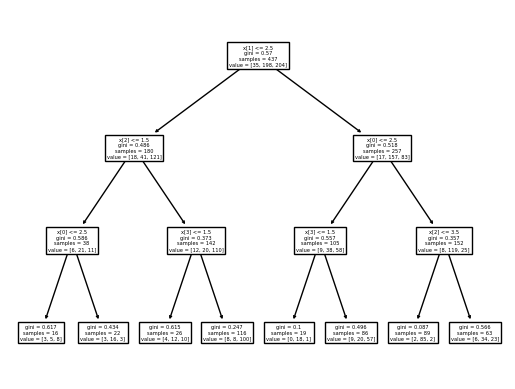

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn import tree

# Veri kümesini yükle
def importdata():
    # csv ile web üzerinden de dataset okunabilir.
    balance_data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data', sep=',', header=None)
    # Veri kümesi boyutları 
    print("Dataset uzunluk: ", len(balance_data))
    print("Dataset boyutu: ", balance_data.shape)
    print("Dataset: ", balance_data.head())
    print(balance_data)
    print("-----------------------------------------------------------------------")
    
    # Etiketlerin sayısını hesapla
    label_counts = data[0].value_counts()

    print("L etiket sayısı: ", label_counts.get('L', 0))
    print("R etiket sayısı: ", label_counts.get('R', 0))
    print("B etiket sayısı: ", label_counts.get('B', 0))
    print("-----------------------------------------------------------------------")

    return balance_data

# Veri kümesini böl
def splitdataset(balance_data):
    # Özellik ve etiketleri ayır
    X = balance_data.values[:, 1:5]
    Y = balance_data.values[:, 0]
    
    # Veriyi eğitim ve test setlerine ayır
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)
    return X, Y, X_train, X_test, y_train, y_test

# Gini indexe göre eğitim yap
def train_using_gini(X_train, y_train):
    # Karar ağacı sınıflandırıcısı oluşturma
    clf_gini = tree.DecisionTreeClassifier(criterion='gini', random_state=100, max_depth=3, min_samples_leaf=5)
    clf_gini.fit(X_train, y_train)
    print('Gini Ağacı')
    tree.plot_tree(clf_gini) # Ağacı çizdirme
    return clf_gini

# Entropi indexine göre eğitim yap
def train_using_entropy(X_train, y_train):
    # Karar ağacı sınıflandırıcısı oluşturma
    clf_entropy = tree.DecisionTreeClassifier(criterion='entropy', random_state=100, max_depth=3, min_samples_leaf=5)
    clf_entropy.fit(X_train, y_train)
    return clf_entropy

# Tahmin yapma
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Tahmin Edilen Değerler")
    print(y_pred)
    return y_pred

# Doğruluk hesaplama
def cal_accuracy(y_test, y_pred):
    print("Confusion matrix: ", confusion_matrix(y_test, y_pred))
    print("Accuracy: ", accuracy_score(y_test, y_pred)*100)
    print("Report: ", classification_report(y_test, y_pred))

# Ana kod
data = importdata()
X, Y, X_train, X_test, y_train, y_test = splitdataset(data)

clf_gini = train_using_gini(X_train, y_train)
clf_entropy = train_using_entropy(X_train, y_train)

print("Gini index kullanarak sonuçlar:")
y_pred_gini = prediction(X_test, clf_gini)
cal_accuracy(y_test, y_pred_gini)

print("Entropi kullanarak sonuçlar:")
y_pred_entropy = prediction(X_test, clf_entropy)
cal_accuracy(y_test, y_pred_entropy)


In [20]:
data.keys()

Index([0, 1, 2, 3, 4], dtype='int64')

In [21]:
!pip install graphviz

  Obtaining dependency information for graphviz from https://files.pythonhosted.org/packages/00/be/d59db2d1d52697c6adc9eacaf50e8965b6345cc143f671e1ed068818d5cf/graphviz-0.20.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/47.1 kB ? eta -:--:--
   -------------------------- ------------- 30.7/47.1 kB 640.0 kB/s eta 0:00:01
   ---------------------------------------- 47.1/47.1 kB 585.5 kB/s eta 0:00:00


In [25]:
import graphviz
dot_data = tree.export_graphviz(clf_gini, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("Balance")

'Balance.pdf'

### Naive Bayes Sınıflandırıcı

In [27]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
digits = load_digits()

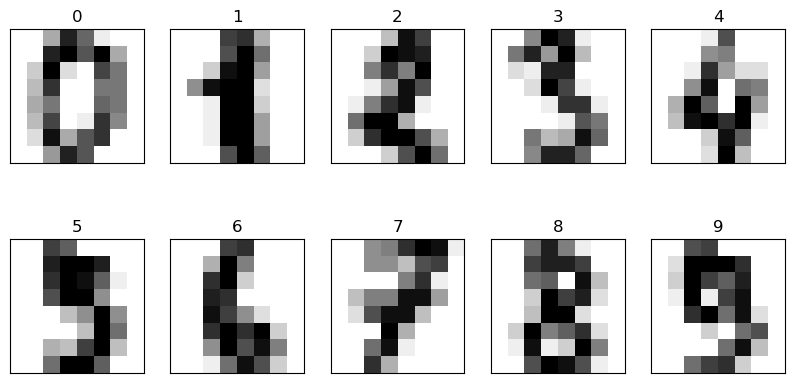

In [31]:
fi,axes = plt.subplots(nrows = 2, ncols = 5, figsize = (10,5),subplot_kw = {"xticks" : [],"yticks":[]})
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i],cmap="binary", interpolation="nearest")
    ax.set_title(digits.target[i])
plt.show()

In [34]:
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2, random_state = 42)


In [35]:
nb_clf = MultinomialNB()
nb_clf.fit(X_train,y_train)
y_pred = nb_clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.87      0.71      0.78        28
           2       0.86      0.94      0.90        33
           3       1.00      0.88      0.94        34
           4       0.94      1.00      0.97        46
           5       0.97      0.83      0.90        47
           6       0.97      0.97      0.97        35
           7       0.92      1.00      0.96        34
           8       0.82      0.93      0.87        30
           9       0.77      0.85      0.81        40

    accuracy                           0.91       360
   macro avg       0.91      0.91      0.91       360
weighted avg       0.92      0.91      0.91       360



In [38]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[32  0  0  0  1  0  0  0  0  0]
 [ 0 20  4  0  0  0  0  0  2  2]
 [ 0  1 31  0  0  0  0  0  1  0]
 [ 0  0  1 30  0  0  0  0  2  1]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 39  1  0  0  7]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 34  0  0]
 [ 0  2  0  0  0  0  0  0 28  0]
 [ 0  0  0  0  1  1  0  3  1 34]]


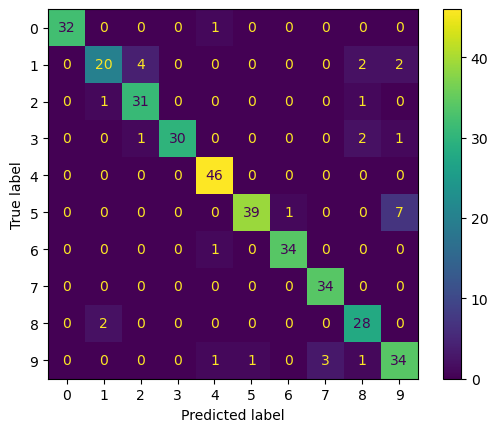

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()